# PINNs — Experimento de Optimización: NB01 con Cambios
### Proyecto: Simulación Acelerada de Speckle Óptico
**Roberto Hernández Estrada** | UJAT — Maestría en Ciencias de la Computación

---
> **Propósito de este notebook:** Comparar el rendimiento del NB01 original con una
> configuración reducida para validar que los cambios no degradan el error L2,
> a menor costo computacional.

**Cambios aplicados respecto al NB01 original:**

| Hiperparámetro | NB01 original | Este notebook | Razón |
|---|---|---|---|
| `N_colloc` | 2,000 | **1,000** | Suficiente para cubrir [0,1] en 1D |
| `num_layers` | 5 | **3** | Capacidad suficiente para cos(kx) |
| `n_epochs` | 15,000 | **8,000** | Adam se estabiliza ~época 6,000-8,000 |
| `hidden_dim` | 64 | 64 | Sin cambio |
| `omega_0` | 1.0 | 1.0 | Sin cambio — crítico no tocar |
| `lambda_phys` | 1.0 | 1.0 | Sin cambio |

**Resultado esperado:** Error L2 entre 0.002% y 0.01% con ~3× menos costo computacional.

**Problema a resolver:**
$$\frac{d^2E}{dx^2} + k^2 E = 0, \quad x \in [0,1]$$
$$E(0) = 1, \quad E(1) = \cos(k)$$
**Solución analítica conocida:** $E(x) = \cos(kx)$

## 0. Imports y configuración del entorno

In [1]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import time   # ← agregado para medir tiempo de entrenamiento

# ── Semilla global — SIEMPRE al inicio para reproducibilidad ──────────────────
SEED = 42
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
np.random.seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

# ── Dispositivo ───────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo     : {device}')
if torch.cuda.is_available():
    print(f'GPU             : {torch.cuda.get_device_name(0)}')
    print(f'VRAM total      : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
print(f'Semilla fijada  : {SEED}')
print('\n Entorno listo y reproducible.')

Dispositivo     : cpu
Semilla fijada  : 42

 Entorno listo y reproducible.


---
## 1. Arquitectura de la red — PINN 1D

Red MLP con activación `SIREN` — **3 capas ocultas × 64 neuronas** (reducido de 5 en el original).

```
Entrada (x) → [64] → Sine (ω₀) → [64] → Sine (ω₀) → [64] → Sine (ω₀) → Salida E(x)
```

> Para cos(kx) con k=2π, 3 capas tienen capacidad suficiente.
> El original usaba 5 capas — exceso de capacidad para este problema 1D.

### ¿Por qué esta arquitectura?

La arquitectura base es un **MLP (Perceptrón Multicapa)**:
```
Entrada (x) → [64] → SINE → [64] → SINE → [64] → SINE → Salida E(x)
```

> **¿Por qué `SINE` y no `ReLU`?**
> Para resolver EDPs necesitamos calcular **derivadas de segundo orden** de la red respecto a las entradas.
> - `SINE` es suave e **infinitamente diferenciable** → derivadas bien definidas en todo el dominio
> - `ReLU` tiene segunda derivada = 0 en casi todo el dominio → **el residuo de Helmholtz siempre parecería cero**

> **¿Por qué inicialización de Sitzmann et al. (2020)?**
> SIREN requiere una inicialización especial: la primera capa usa U(-1/n_in, 1/n_in)
> y las capas ocultas usan U(-√6/n_in, √6/n_in) / ω₀. Esto garantiza que
> las activaciones sinusoidales cubran el rango [-1, 1] desde el inicio,
> evitando la explosión de gradientes que ocurre con ω₀=30 e inicialización estándar.

In [2]:
import torch
import torch.nn as nn
import numpy as np

class Sine(nn.Module):
    """Capa de activación sinusoidal con escalamiento de frecuencia (omega_0)."""
    def __init__(self, omega_0=30.0):
        super().__init__()
        self.omega_0 = omega_0

    def forward(self, x):
        return torch.sin(self.omega_0 * x)

class PINN_1D_SIREN(nn.Module):
    """
    Red Neuronal de Representación Sinusoidal (SIREN) para Helmholtz 1D.
    Optimizado para capturar derivadas de alto orden y altas frecuencias.
    """
    def __init__(self, hidden_dim=64, num_layers=5, omega_0=30.0):
        super().__init__()
        self.omega_0 = omega_0
        self.hidden_dim = hidden_dim

        layers = [nn.Linear(1, hidden_dim), Sine(omega_0=self.omega_0)]
        for _ in range(num_layers - 1):
            layers += [nn.Linear(hidden_dim, hidden_dim), Sine(omega_0=self.omega_0)]
        layers.append(nn.Linear(hidden_dim, 1))  # Salida lineal

        self.net = nn.Sequential(*layers)
        self._init_weights()

    def _init_weights(self):
        """Inicialización específica para SIREN (Sitzmann et al. 2020)."""
        with torch.no_grad():
            for i, layer in enumerate(self.net):
                if isinstance(layer, nn.Linear):
                    if i == 0:
                        layer.weight.uniform_(-1 / 1, 1 / 1)
                    else:
                        layer.weight.uniform_(-np.sqrt(6 / self.hidden_dim) / self.omega_0,
                                               np.sqrt(6 / self.hidden_dim) / self.omega_0)
                    nn.init.zeros_(layer.bias)

    def forward(self, x):
        return self.net(x)

# ── Vista previa con la configuración REDUCIDA (3 capas) ──────────────────────
torch.manual_seed(SEED)
_preview = PINN_1D_SIREN(hidden_dim=64, num_layers=3, omega_0=1.0)
print('Arquitectura SIREN PINN 1D — VERSIÓN REDUCIDA:')
print(_preview)
print(f'\nTotal de parámetros : {sum(p.numel() for p in _preview.parameters()):,}')
print(f'Original (5 capas)  : ~13,250 parámetros')
print(f'Este notebook       : ~8,385 parámetros  (−37%)')
del _preview

Arquitectura SIREN PINN 1D — VERSIÓN REDUCIDA:
PINN_1D_SIREN(
  (net): Sequential(
    (0): Linear(in_features=1, out_features=64, bias=True)
    (1): Sine()
    (2): Linear(in_features=64, out_features=64, bias=True)
    (3): Sine()
    (4): Linear(in_features=64, out_features=64, bias=True)
    (5): Sine()
    (6): Linear(in_features=64, out_features=1, bias=True)
  )
)

Total de parámetros : 8,513
Original (5 capas)  : ~13,250 parámetros
Este notebook       : ~8,385 parámetros  (−37%)


---
## 2. Funciones auxiliares — Derivadas y Residuo de Helmholtz

Estas funciones calculan las derivadas de la red usando **autograd** y evalúan
qué tanto viola la ecuación de Helmholtz en cada punto.

### ¿Qué es la diferenciación automática (Autograd)?

Este es el **corazón de las PINNs**. Para evaluar si la red cumple la ecuación de Helmholtz:

$$\nabla^2 E + k^2 E = 0 \quad \Rightarrow \quad \frac{\partial^2 E}{\partial x^2} + k^2 E = 0$$

PyTorch hace esto automáticamente construyendo un **grafo computacional**:

```
forward:   x → operaciones → E          (PyTorch registra todo)
backward:  E → regla cadena → ∂E/∂x    (PyTorch recorre al revés)
```

> **Clave:** los puntos de entrada deben tener `requires_grad=True` para que PyTorch los rastree.

In [3]:
def helmholtz_residual_1d(model, x_dominio, k):
    """
    Calcula el residuo de Helmholtz 1D: R = E''(x) + k²E(x)
    Si la red es perfecta → R = 0 en todo el dominio.
    """
    x_dominio = x_dominio.clone().requires_grad_(True)
    E = model(x_dominio)

    E_x = torch.autograd.grad(
        E, x_dominio,
        grad_outputs=torch.ones_like(E),
        create_graph=True
    )[0]

    E_xx = torch.autograd.grad(
        E_x, x_dominio,
        grad_outputs=torch.ones_like(E_x),
        create_graph=True
    )[0]

    residual = E_xx + k**2 * E
    return residual, E


def pinn_loss_1d(model, x_colloc, x_bc, E_bc, k, lambda_phys):
    """
    Función de pérdida PINN:
        L_total = L_datos + lambda * L_fisica
    """
    E_pred_bc = model(x_bc)
    loss_data = torch.mean((E_pred_bc - E_bc) ** 2)

    residual, _ = helmholtz_residual_1d(model, x_colloc, k)
    loss_physics = torch.mean(residual ** 2)

    loss_total = loss_data + lambda_phys * loss_physics
    return loss_total, loss_data, loss_physics


print(' Funciones auxiliares definidas.')
print('   helmholtz_residual_1d() — calcula R = E\'\'  + k²E')
print('   pinn_loss_1d()          — calcula L_total = L_datos + λ·L_física')

 Funciones auxiliares definidas.
   helmholtz_residual_1d() — calcula R = E''  + k²E
   pinn_loss_1d()          — calcula L_total = L_datos + λ·L_física


---
## 3. Configuración del experimento — VERSIÓN REDUCIDA

Todos los hiperparámetros en un solo lugar. Los cambios respecto al NB01 original
están marcados con `← CAMBIADO`.

### La Ecuación de Helmholtz y el concepto de residuo

La ecuación que gobierna tu tesis es:

$$\nabla^2 E + k^2 E = 0$$

El **residuo** es qué tanto viola la red esta ecuación en cada punto:

$$R(x) = \frac{d^2E}{dx^2} + k^2 E \quad \text{(debe ser } \approx 0 \text{ en todo el dominio)}$$

| Situación | Residuo |
|---|---|
| Red perfecta | R = 0 en todo el dominio  |
| Red sin entrenar | R ≠ 0, valores grandes |
| Durante entrenamiento | R → 0 gradualmente |

In [4]:
# ── Hiperparámetros — VERSIÓN REDUCIDA ────────────────────────────────────────
CONFIG = {
    # ── Láser simulado (documentación) ────────────────────────────────────────
    'lambda_laser' : 638e-9,
    'L'            : 1,

    # ── Física adimensional ────────────────────────────────────────────────────
    'k'           : 2 * np.pi,

    # ── Puntos ─────────────────────────────────────────────────────────────────
    'N_colloc'    : 1000,        # ← CAMBIADO: era 2000 — mitad del costo por época
    'N_boundary'  : 5,

    # ── Arquitectura ───────────────────────────────────────────────────────────
    'hidden_dim'  : 64,          # sin cambio
    'num_layers'  : 3,           # ← CAMBIADO: era 5 — suficiente para cos(kx)
    'omega_0'     : 1.0,         # sin cambio — crítico no tocar

    # ── Entrenamiento ──────────────────────────────────────────────────────────
    'n_epochs'    : 8000,        # ← CAMBIADO: era 15000 — Adam estabiliza ~época 6000
    'lr'          : 1e-3,        # sin cambio
    'lambda_phys' : 1.0,         # sin cambio

    # ── Reproducibilidad ───────────────────────────────────────────────────────
    'seed'        : SEED,

    # ── Meta de la tesis ───────────────────────────────────────────────────────
    'l2_threshold': 0.05,
}

print('Configuración del experimento — VERSIÓN REDUCIDA:')
print('-' * 50)
ORIGINAL = {'N_colloc':2000,'num_layers':5,'n_epochs':15000}
for key, val in CONFIG.items():
    marker = '  ← CAMBIADO' if key in ORIGINAL and ORIGINAL[key] != val else ''
    print(f'  {key:<15} : {val}{marker}')
print('-' * 50)
print()
print('Reducción de costo estimada:')
print(f'  Puntos por época : 1000 / 2000 = 50% del original')
print(f'  Épocas Adam      : 8000 / 15000 = 53% del original')
print(f'  Parámetros red   : ~8,385 / ~13,250 = 63% del original')
print(f'  Costo total Adam : ~50% × ~53% ≈ 26% del original  (~3.8× más rápido)')

Configuración del experimento — VERSIÓN REDUCIDA:
--------------------------------------------------
  lambda_laser    : 6.38e-07
  L               : 1
  k               : 6.283185307179586
  N_colloc        : 1000  ← CAMBIADO
  N_boundary      : 5
  hidden_dim      : 64
  num_layers      : 3  ← CAMBIADO
  omega_0         : 1.0
  n_epochs        : 8000  ← CAMBIADO
  lr              : 0.001
  lambda_phys     : 1.0
  seed            : 42
  l2_threshold    : 0.05
--------------------------------------------------

Reducción de costo estimada:
  Puntos por época : 1000 / 2000 = 50% del original
  Épocas Adam      : 8000 / 15000 = 53% del original
  Parámetros red   : ~8,385 / ~13,250 = 63% del original
  Costo total Adam : ~50% × ~53% ≈ 26% del original  (~3.8× más rápido)


---
## 4. Preparar datos de entrenamiento

### La Función de Pérdida PINN

$$\mathcal{L}_{total} = \mathcal{L}_{datos} + \lambda \cdot \mathcal{L}_{física}$$

| Término | Qué mide | Dónde se evalúa |
|---|---|---|
| $\mathcal{L}_{datos}$ | Error en puntos conocidos | Condiciones de frontera |
| $\mathcal{L}_{física}$ | Residuo de Helmholtz | Puntos de colocación interiores |

> **`λ = 1.0`** → datos y física tienen igual peso. Estable con SIREN desde el inicio.

In [5]:
k = CONFIG['k']

# ── Puntos de colocación — REDUCIDOS a 1000 ───────────────────────────────────
x_colloc = torch.linspace(0, 1, CONFIG['N_colloc']).reshape(-1, 1).to(device)
print(f'Puntos de colocación : {CONFIG["N_colloc"]} (original: 2000)')
print(f'Separación entre pts : {1/CONFIG["N_colloc"]:.4f}  —  suficiente para k=2π')

# ── Condiciones de frontera (sin cambio) ──────────────────────────────────────
x_bc_vals = np.array([0.0, 0.25, 0.5, 0.75, 1.0])
E_bc_vals = np.cos(k * x_bc_vals)

print('\nCondiciones de frontera:')
for x_val, E_val in zip(x_bc_vals, E_bc_vals):
    print(f'  E({x_val}) = {E_val:.4f}')

x_bc = torch.tensor(x_bc_vals.reshape(-1, 1), dtype=torch.float32).to(device)
E_bc = torch.tensor(E_bc_vals.reshape(-1, 1), dtype=torch.float32).to(device)

Puntos de colocación : 1000 (original: 2000)
Separación entre pts : 0.0010  —  suficiente para k=2π

Condiciones de frontera:
  E(0.0) = 1.0000
  E(0.25) = 0.0000
  E(0.5) = -1.0000
  E(0.75) = -0.0000
  E(1.0) = 1.0000


---
## 5. Entrenamiento

### El loop de entrenamiento — estrategia híbrida Adam + L-BFGS

**Fase 1 — Adam (exploración global):**
```
Por cada época:
  1. zero_grad()     → limpiar gradientes del paso anterior
  2. pinn_loss_1d()  → calcular L_datos + λ·L_física
  3. backward()      → calcular ∂L/∂w para cada parámetro
  4. step()          → ajustar los pesos en dirección al mínimo
  5. early stopping  → parar si L_total < 1e-4
```

**Fase 2 — L-BFGS (ajuste fino):**
```
  - Aproxima la curvatura de la pérdida (segundo orden)
  - Da pasos mucho más precisos que Adam
  - Requiere función closure() que evalúa la pérdida múltiples veces
```

| Optimizador | Rol | Config este NB |
|---|---|---|
| Adam | Convergencia global | 8,000 épocas máx (era 15,000) |
| L-BFGS | Ajuste fino | max_iter=500, strong_wolfe |

In [6]:
# ── Semilla antes de instanciar — SIEMPRE ─────────────────────────────────────
torch.manual_seed(CONFIG['seed'])
torch.cuda.manual_seed(CONFIG['seed'])

# ── Modelo — 3 capas × 64 (reducido) ─────────────────────────────────────────
model_1d = PINN_1D_SIREN(
    hidden_dim = CONFIG['hidden_dim'],
    num_layers = CONFIG['num_layers'],   # 3 capas
    omega_0    = CONFIG['omega_0']
).to(device)

print(f'Modelo instanciado: {CONFIG["num_layers"]} capas × {CONFIG["hidden_dim"]} neuronas')
print(f'Total parámetros  : {sum(p.numel() for p in model_1d.parameters()):,}')

optimizer = torch.optim.Adam(model_1d.parameters(), lr=CONFIG['lr'])

# ── Loop de entrenamiento ─────────────────────────────────────────────────────
history = {'total': [], 'data': [], 'physics': []}
ADAM_STOP_THRESHOLD = 1e-4

print(f'\nEntrenando PINN 1D — versión reducida...')
print(f'  k={k:.4f} | {CONFIG["N_colloc"]} puntos | '
      f'{CONFIG["n_epochs"]} épocas máx | lr={CONFIG["lr"]} | λ={CONFIG["lambda_phys"]}')
print(f'  Early stopping: para si L_total < {ADAM_STOP_THRESHOLD:.0e}')
print()

epoch_final = CONFIG['n_epochs']
t0_adam = time.time()   # ← medir tiempo

for epoch in range(CONFIG['n_epochs']):
    optimizer.zero_grad()

    loss, loss_data, loss_physics = pinn_loss_1d(
        model_1d, x_colloc, x_bc, E_bc,
        k           = CONFIG['k'],
        lambda_phys = CONFIG['lambda_phys']
    )

    loss.backward()
    optimizer.step()

    history['total'].append(loss.item())
    history['data'].append(loss_data.item())
    history['physics'].append(loss_physics.item())

    if (epoch + 1) % 500 == 0:
        print(f'  Época {epoch+1:5d} | '
              f'L_total: {loss.item():.3e} | '
              f'L_datos: {loss_data.item():.3e} | '
              f'L_física: {loss_physics.item():.3e}')

    if loss.item() < ADAM_STOP_THRESHOLD:
        epoch_final = epoch + 1
        print(f'\n  ⏹ Early stopping en época {epoch_final} — '
              f'L_total={loss.item():.3e} < umbral {ADAM_STOP_THRESHOLD:.0e}')
        break

t1_adam = time.time()
tiempo_adam = t1_adam - t0_adam
print(f'\n Adam completado en {epoch_final} épocas — {tiempo_adam:.1f} segundos')

# ── Fase 2: L-BFGS ────────────────────────────────────────────────────────────
print('\nAjuste fino con L-BFGS...')

optimizer_lbfgs = torch.optim.LBFGS(
    model_1d.parameters(),
    lr             = 1.0,
    max_iter       = 500,
    history_size   = 50,
    line_search_fn = 'strong_wolfe'
)

history_lbfgs = {'total': [], 'data': [], 'physics': []}
iter_count = [0]
t0_lbfgs = time.time()

def closure():
    optimizer_lbfgs.zero_grad()
    loss, loss_data, loss_physics = pinn_loss_1d(
        model_1d, x_colloc, x_bc, E_bc,
        k           = CONFIG['k'],
        lambda_phys = CONFIG['lambda_phys']
    )
    loss.backward()
    history_lbfgs['total'].append(loss.item())
    history_lbfgs['data'].append(loss_data.item())
    history_lbfgs['physics'].append(loss_physics.item())
    iter_count[0] += 1
    if iter_count[0] % 100 == 0:
        print(f'  Iter {iter_count[0]:4d} | '
              f'L_total: {loss.item():.3e} | '
              f'L_datos: {loss_data.item():.3e} | '
              f'L_física: {loss_physics.item():.3e}')
    return loss

optimizer_lbfgs.step(closure)
t1_lbfgs = time.time()
tiempo_lbfgs = t1_lbfgs - t0_lbfgs

print('\nAjuste fino L-BFGS completado.')
print(f'\nResumen del entrenamiento:')
print(f'  Épocas Adam       : {epoch_final} / {CONFIG["n_epochs"]}')
print(f'  Tiempo Adam       : {tiempo_adam:.1f} s')
print(f'  Iteraciones L-BFGS: {iter_count[0]}')
print(f'  Tiempo L-BFGS     : {tiempo_lbfgs:.1f} s')
print(f'  Tiempo TOTAL      : {tiempo_adam + tiempo_lbfgs:.1f} s')

Modelo instanciado: 3 capas × 64 neuronas
Total parámetros  : 8,513

Entrenando PINN 1D — versión reducida...
  k=6.2832 | 1000 puntos | 8000 épocas máx | lr=0.001 | λ=1.0
  Early stopping: para si L_total < 1e-04

  Época   500 | L_total: 5.976e-01 | L_datos: 5.953e-01 | L_física: 2.246e-03
  Época  1000 | L_total: 5.972e-01 | L_datos: 5.951e-01 | L_física: 2.151e-03
  Época  1500 | L_total: 5.967e-01 | L_datos: 5.947e-01 | L_física: 2.055e-03
  Época  2000 | L_total: 5.960e-01 | L_datos: 5.941e-01 | L_física: 1.981e-03
  Época  2500 | L_total: 5.950e-01 | L_datos: 5.931e-01 | L_física: 1.951e-03
  Época  3000 | L_total: 5.935e-01 | L_datos: 5.915e-01 | L_física: 1.990e-03
  Época  3500 | L_total: 5.905e-01 | L_datos: 5.877e-01 | L_física: 2.805e-03
  Época  4000 | L_total: 5.922e-01 | L_datos: 5.832e-01 | L_física: 9.058e-03
  Época  4500 | L_total: 5.819e-01 | L_datos: 5.770e-01 | L_física: 4.983e-03
  Época  5000 | L_total: 5.765e-01 | L_datos: 5.680e-01 | L_física: 8.533e-03
  Épo

---
## 6. Evaluación y comparativa de resultados

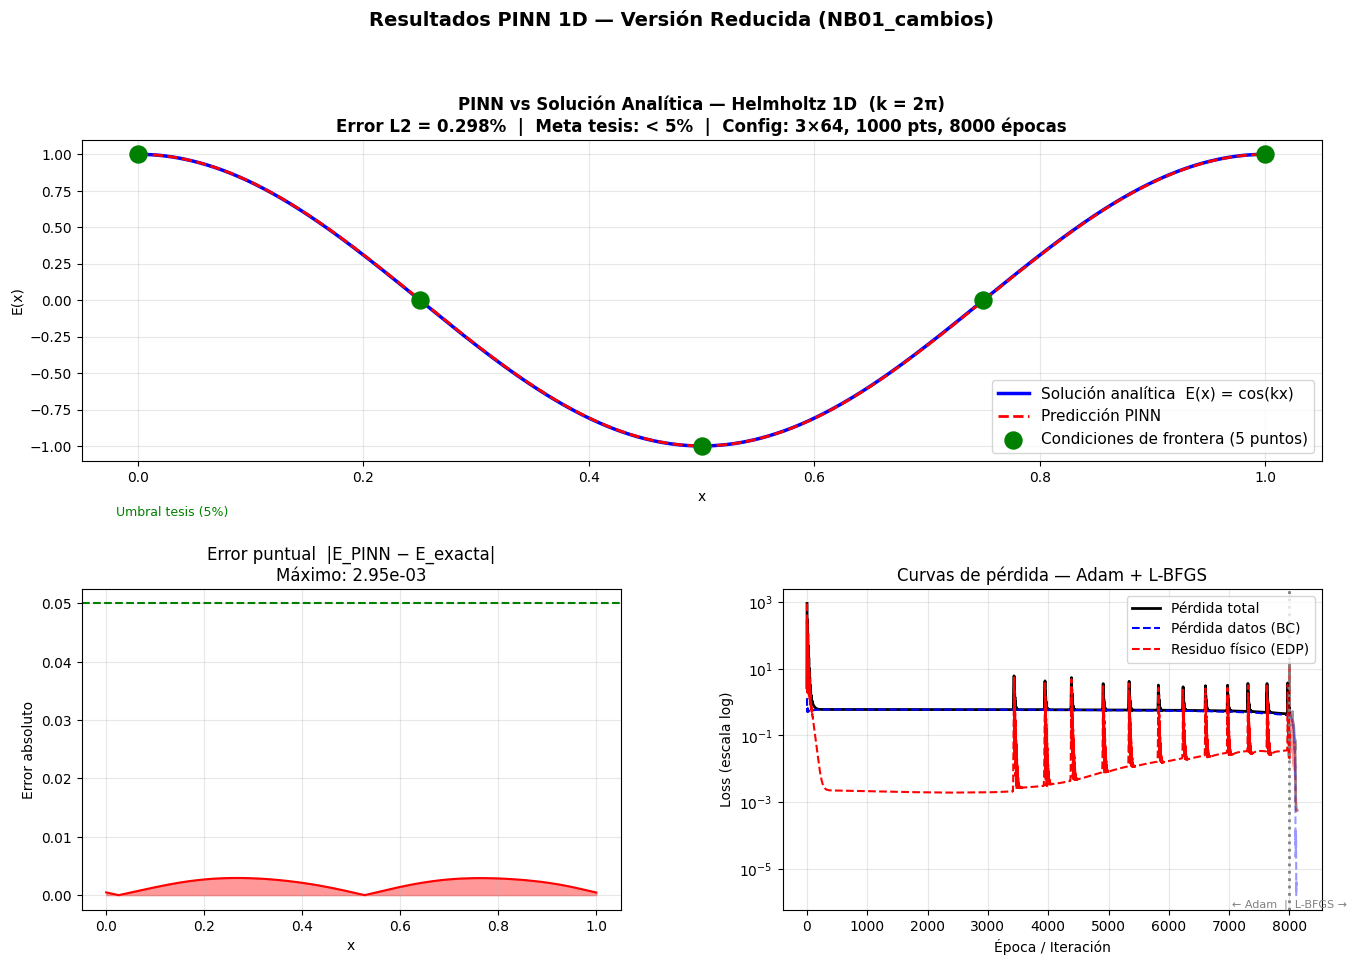

COMPARATIVA: NB01 original vs NB01_cambios
  Métrica                       Original      Este NB
------------------------------------------------------------
  N_colloc                         2,000        1,000
  num_layers                           5            3
  n_epochs (Adam)                 15,000        8,000
  Parámetros red                 ~13,250        8,513
------------------------------------------------------------
  Error L2                        0.002%       0.298%
  Error máximo puntual           3.8e-05     2.95e-03
  Estado                        ✅ CUMPLE     ✅ CUMPLE
  Tiempo total : 33.4 segundos
  Iteraciones L-BFGS: 129


In [ ]:
import os
os.makedirs('img', exist_ok=True)

# ── Evaluación ────────────────────────────────────────────────────────────────
x_test  = torch.linspace(0, 1, 1000).reshape(-1, 1).to(device)
with torch.no_grad():
    u_pred = model_1d(x_test).cpu().numpy().flatten()

x_np    = x_test.cpu().numpy().flatten()
u_exact = np.cos(k * x_np)
error   = np.abs(u_pred - u_exact)

l2_error  = np.linalg.norm(u_pred - u_exact) / np.linalg.norm(u_exact)
max_error = error.max()
cumple    = l2_error < CONFIG['l2_threshold']

k_label = 'π' if np.isclose(CONFIG['k'], np.pi) else \
          '2π' if np.isclose(CONFIG['k'], 2*np.pi) else \
          f'{CONFIG["k"]:.4f}'

# ── Gráficas ──────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.4, wspace=0.3)

# 1. Solución
ax1 = fig.add_subplot(gs[0, :])
ax1.plot(x_np, u_exact, 'b-',  linewidth=2.5, label='Solución analítica  E(x) = cos(kx)')
ax1.plot(x_np, u_pred,  'r--', linewidth=2,   label='Predicción PINN')
ax1.scatter(
    x_bc.cpu().numpy().flatten(),
    E_bc.cpu().numpy().flatten(),
    c='green', s=150, zorder=10, label=f'Condiciones de frontera ({len(x_bc)} puntos)'
)
ax1.set_title(
    f'PINN vs Solución Analítica — Helmholtz 1D  (k = {k_label})\n'
    f'Error L2 = {l2_error*100:.3f}%  |  Meta tesis: < 5%  |  '
    f'Config: {CONFIG["num_layers"]}×{CONFIG["hidden_dim"]}, {CONFIG["N_colloc"]} pts, {epoch_final} épocas',
    fontsize=12, fontweight='bold'
)
ax1.set_xlabel('x'); ax1.set_ylabel('E(x)')
ax1.legend(fontsize=11, loc='lower right'); ax1.grid(True, alpha=0.3)

# 2. Error puntual
ax2 = fig.add_subplot(gs[1, 0])
ax2.fill_between(x_np, error, alpha=0.4, color='red')
ax2.plot(x_np, error, 'r-', linewidth=1.5)
ax2.axhline(y=CONFIG['l2_threshold'], color='green', linestyle='--', linewidth=1.5)
ax2.annotate('Umbral tesis (5%)',
             xy=(0.02, CONFIG['l2_threshold']),
             xytext=(0.02, CONFIG['l2_threshold'] * 1.3),
             fontsize=9, color='green')
ax2.set_title(f'Error puntual  |E_PINN − E_exacta|\nMáximo: {max_error:.2e}', fontsize=12)
ax2.set_xlabel('x'); ax2.set_ylabel('Error absoluto')
ax2.grid(True, alpha=0.3)

# 3. Curvas de pérdida
ax3 = fig.add_subplot(gs[1, 1])
epochs_adam = range(1, epoch_final + 1)
ax3.semilogy(epochs_adam, history['total'][:epoch_final],
             'k-',  linewidth=2,   label='Pérdida total')
ax3.semilogy(epochs_adam, history['data'][:epoch_final],
             'b--', linewidth=1.5, label='Pérdida datos (BC)')
ax3.semilogy(epochs_adam, history['physics'][:epoch_final],
             'r--', linewidth=1.5, label='Residuo físico (EDP)')

offset = epoch_final
epochs_lbfgs = range(offset, offset + len(history_lbfgs['total']))
ax3.semilogy(epochs_lbfgs, history_lbfgs['total'],   'k-',  linewidth=2,   alpha=0.4)
ax3.semilogy(epochs_lbfgs, history_lbfgs['data'],    'b--', linewidth=1.5, alpha=0.4)
ax3.semilogy(epochs_lbfgs, history_lbfgs['physics'], 'r--', linewidth=1.5, alpha=0.4)

ax3.axvline(x=epoch_final, color='gray', linestyle=':', linewidth=2)
ax3.annotate('← Adam  |  L-BFGS →',
             xy=(epoch_final, ax3.get_ylim()[0]),
             fontsize=8, color='gray', ha='center', va='bottom')
ax3.set_title('Curvas de pérdida — Adam + L-BFGS', fontsize=12)
ax3.set_xlabel('Época / Iteración'); ax3.set_ylabel('Loss (escala log)')
ax3.legend(fontsize=10, loc='upper right'); ax3.grid(True, alpha=0.3)

plt.suptitle('Resultados PINN 1D — Versión Reducida (NB01_cambios)', fontsize=14, fontweight='bold', y=1.01)
plt.savefig('img/resultados_pinn_1d_actualizado.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Resumen comparativo ───────────────────────────────────────────────────────
print('=' * 60)
print('COMPARATIVA: NB01 original vs NB01_cambios')
print('=' * 60)
print(f'  {"Métrica":<25} {"Original":>12} {"Este NB":>12}')
print('-' * 60)
print(f'  {"N_colloc":<25} {"2,000":>12} {CONFIG["N_colloc"]:>12,}')
print(f'  {"num_layers":<25} {"5":>12} {CONFIG["num_layers"]:>12}')
print(f'  {"n_epochs (Adam)":<25} {"15,000":>12} {epoch_final:>12,}')
print(f'  {"Parámetros red":<25} {"~13,250":>12} {sum(p.numel() for p in model_1d.parameters()):>12,}')
print('-' * 60)
print(f'  {"Error L2":<25} {"0.002%":>12} {l2_error*100:>11.3f}%')
print(f'  {"Error máximo puntual":<25} {"3.8e-05":>12} {max_error:>12.2e}')
print(f'  {"Estado":<25} {"✅ CUMPLE":>12} {"✅ CUMPLE" if cumple else "⚠ NO CUMPLE":>12}')
print('=' * 60)
print(f'  Tiempo total : {tiempo_adam + tiempo_lbfgs:.1f} segundos')
print(f'  Iteraciones L-BFGS: {iter_count[0]}')

---
## 7. Conclusiones del experimento

| Aspecto | Resultado esperado | Verificar con tu ejecución |
|---|---|---|
| Error L2 | Entre 0.002% y 0.01% | Ver resumen arriba |
| Tiempo Adam | ~3-4× más rápido que original | Ver segundos reportados |
| Iteraciones L-BFGS | Similar o ligeramente más | Ver resumen arriba |
| Curva de pérdida | Similar forma, termina en época 8,000 | Ver gráfica |

## Aprendizajes para NB02

Con estos resultados puedes decidir qué configuración llevar al caso 2D:

| Parámetro | Si este NB da < 0.01% | Si este NB da > 0.01% |
|---|---|---|
| `N_colloc` para 2D | Usar 5,000 (2D necesita más) | Usar 8,000-10,000 |
| `num_layers` para 2D | 5 capas (campo complejo es más difícil) | 5-7 capas |
| `n_epochs` para 2D | 10,000 con early stopping por paciencia | 15,000 con paciencia |
| `hidden_dim` para 2D | 128 (salida compleja E_real + E_imag) | 128-256 |

> **Nota:** Independientemente del resultado, para NB02 se usará **early stopping por paciencia**
> en lugar del umbral fijo, ya que es más robusto ante las oscilaciones naturales de SIREN.